# Evaluation Metrics for Image Inpainting

<div style="margin:.3rem 0 1rem;font-size:.9em;color:#555;display:flex;align-items:center;gap:.35rem;font-family:monospace">
  <time datetime="2026-05-02">2 May 2026</time>
</div>

<a href="https://colab.research.google.com/github/shahaliyev/csci4701/blob/main/docs/supplementary/inpainting_metrics.ipynb"
   target="_blank" rel="noopener">
  <img
    src="https://colab.research.google.com/assets/colab-badge.svg"
    alt="Open in Colab"
   loading="lazy" decoding="async"/>
</a>

IMAGE INPAINTING reconstructs missing or corrupted regions of an image using the surrounding visible context. Since different metrics describe different kinds of image quality, this notebook groups them by what they compare: direct pixel values, local visual patterns, deep feature similarity, and sets of generated images. The goal is to understand how each metric is computed, how it behaves visually, and what kind of evaluation claim it supports. The notebook will explain the following metrics before briefly discussing other metrics, losses and distribution-based evaluations:

- MAE, MSE, RMSE
- Peak Signal-to-Noise Ratio (PSNR)
- Structural Similarity Index Measure (SSIM, MS-SSIM)
- Learned Perceptual Image Patch Similarity (LPIPS)

For inpainting, the same metric can be applied to the (i) whole image, (ii) only the missing region, (iii) only the known region, or (iv) the boundary around the mask. This is important because an inpainting model is usually expected to both reconstruct the hole and preserve the visible pixels. Later sections will therefore combine standard image-quality metrics with mask-specific evaluation.

Before introducing the metrics, we first set up a small image example. We load one natural RGB image from the [Oxford-IIIT Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/) dataset, resize and center-crop it to $256 \times 256$, and keep it in the standard image tensor format $(N, C, H, W)$, where $N$ is batch size, $C$ is the number of channels, and $H,W$ are height and width.  After loading the _reference image_ $x$, we create three simple variants: a _darkened image_, _noisy image_, and _blurred image_. The darkened image changes many pixels smoothly, the noisy image adds small random deviations across the image, and the blurred image removes local detail. Comparing their scores gives a first intuition for how pixel-wise metrics react to different kinds of numerical error.

In [1]:
import matplotlib.pyplot as plt

# helper function for plotting
def show(images, titles=None, figsize=None):
    if isinstance(images, dict):
        titles, images = list(images.keys()), list(images.values())
    fig, axes = plt.subplots(1, len(images), figsize=figsize or (3 * len(images), 4))
    axes = [axes] if len(images) == 1 else axes
    for ax, img, title in zip(axes, images, titles or [""] * len(images)):
        img = img[0] if img.ndim == 4 else img
        img = img[0] if img.ndim == 3 and img.shape[0] == 1 else img
        img = img.permute(1, 2, 0) if img.ndim == 3 and img.shape[0] == 3 else img
        img = img.detach().cpu().clamp(0, 1)
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()

In [2]:
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor

transform = Compose([Resize(256), CenterCrop(256), ToTensor()])
data = OxfordIIITPet(root="./data", split="test", target_types="category", download=True, transform=transform)

x, label = data[0]
x = x.unsqueeze(0)

x.shape, x.min(), x.max()

(torch.Size([1, 3, 256, 256]), tensor(0.), tensor(1.))

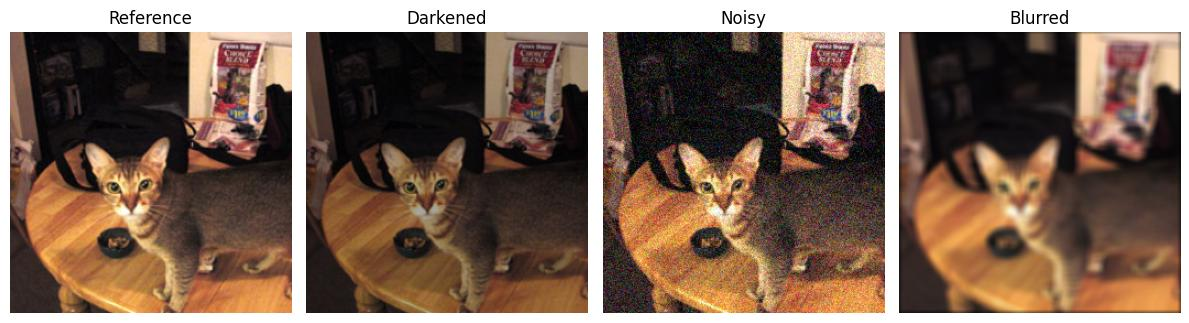

In [3]:
import torch
import torch.nn.functional as F

torch.manual_seed(0)

x_dark = (0.65 * x).clamp(0, 1)
x_noisy = (x + 0.1 * torch.randn_like(x)).clamp(0, 1)
x_blur = F.avg_pool2d(x, kernel_size=7, stride=1, padding=3)

images = {"Reference": x, "Darkened": x_dark, "Noisy": x_noisy, "Blurred": x_blur}
show(images)

Before introducing metrics, we need to talk about **image masking**. Inpainting has a special structure: some pixels are visible in the input, while others are missing and must be reconstructed. We therefore introduce a binary mask $m$, where $m_{i,j}=1$ denotes a known pixel and $m_{i,j}=0$ denotes a missing pixel. This convention matches the common inpainting setup, where the model receives a corrupted image and a mask indicating which pixels are available. Masked and region-specific processing is important in inpainting methods such as _partial convolution_, where convolutions are conditioned only on valid pixels ([Liu et al., 2018](https://arxiv.org/abs/1804.07723)).

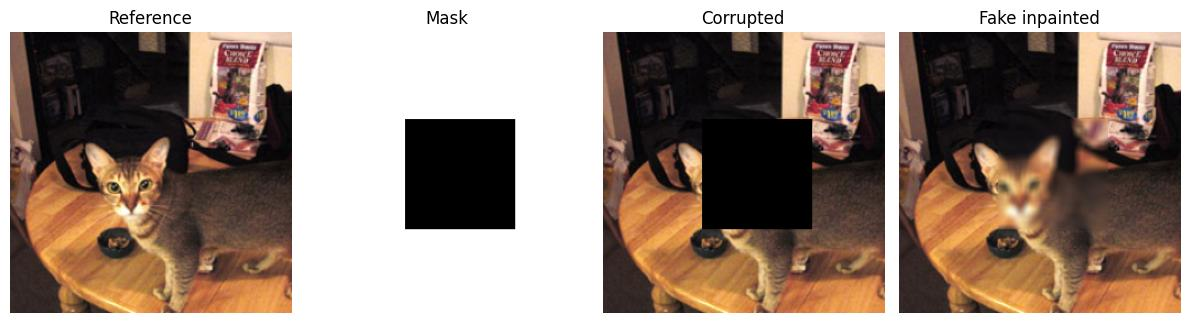

In [4]:
def get_box_mask(x, top=80, left=90, height=100, width=100):
  mask = torch.ones(x.shape[0], 1, x.shape[2], x.shape[3], device=x.device)
  mask[:, :, top:top+height, left:left+width] = 0
  return mask

mask = get_box_mask(x)

x_corrupted = x * mask
x_inpainted = x_corrupted + x_blur * (1 - mask)

show({"Reference": x, "Mask": mask, "Corrupted": x_corrupted, "Fake inpainted": x_inpainted})

In [5]:
# helper functions for masked mean
def get_mean(x, mask=None, eps=1e-8):
    if mask is None:
        return x.mean()
    mask = mask.expand_as(x)
    return (x * mask).sum() / mask.sum().clamp_min(eps)

## Pixel-Wise Error Metrics

The simplest inpainting metrics compare the predicted image $\hat{x}$ directly with the reference image $x$ at the pixel level. These are *full-reference* metrics because they require the original unmasked image. They are fast, deterministic, and easy to interpret as numerical reconstruction error. They are also limited: they do not measure texture quality, object correctness, or perceptual realism. This general limitation of pixel fidelity measures is discussed in classical image-quality literature ([Wang and Bovik, 2009](https://www.ece.uwaterloo.ca/~z70wang/publications/SPM09.pdf)). In practice, these metrics answer one narrow question: how close are the predicted pixel values to the reference pixel values? They are necessary for reporting pixel fidelity, but they should not be interpreted as perceptual realism metrics.

### MAE, MSE, RMSE

_Mean Absolute Error (MAE)_, _Mean Squared Error (MSE)_, and _Root Mean Squared Error (RMSE)_ can be described through one averaged error template:

$$
E_p(x,\hat{x}) =
\left(
\frac{1}{HWC}
\sum_{i=1}^{H}
\sum_{j=1}^{W}
\sum_{c=1}^{C}
\left|x_{i,j,c} - \hat{x}_{i,j,c}\right|^p
\right)^{1/p}.
$$

Here, $x$ is the reference image, $\hat{x}$ is the inpainted prediction, $H$ and $W$ are image height and width, $C$ is the number of channels, and $x_{i,j,c}$ denotes the value at row $i$, column $j$, and channel $c$. The term $\left|x_{i,j,c} - \hat{x}_{i,j,c}\right|$ is the absolute pixel error at one location, $p$ controls how strongly larger errors are penalized, and $\frac{1}{HWC}$ averages the result over all pixels and channels.

When $p=1$, the expression gives MAE. It measures average absolute deviation and treats error linearly, so it is less dominated by a few large mistakes. When $p=2$, the expression gives RMSE. It penalizes larger errors more strongly because errors are squared before averaging, then brought back to the original pixel scale by the square root. MSE is the squared version of RMSE, $\operatorname{MSE}=E_2^2$, so it has the same ranking behavior as RMSE but is reported in squared units. Lower is better for all three metrics, and the optimal value is $0$.

In [6]:
import pandas as pd

# helper function for plotting results
def plot_table(scores, decimals=4):
    table = pd.DataFrame(scores).T
    if isinstance(table.iloc[0, 0], dict):
        table = pd.concat({row: pd.Series(cols) for row, cols in scores.items()}, axis=1).T
    table = table.map(lambda v: v.item() if torch.is_tensor(v) else v)
    return table.round(decimals)

# helper function for calculating scores
def get_scores(x, images, metrics, mask=None, mode="both"):
    if mode in ["mask", "both"] and mask is None:
      raise ValueError("mask must be provided when mode is 'mask' or 'both'")
    scores = {}
    for image_name, img in images.items():
        row = {}
        if mode in ["full", "both"]:
            for metric_name, fn in metrics.items():
                row[f"Full {metric_name}"] = fn(x, img)
        if mode in ["mask", "both"]:
            hole_mask = 1 - mask
            for metric_name, fn in metrics.items():
                row[f"Mask {metric_name}"] = fn(x, img, hole_mask)
        scores[image_name] = row
    return scores

In [7]:
def mae(x, y, mask=None):
    return get_mean((x - y).abs(), mask)

def mse(x, y, mask=None):
    return get_mean((x - y) ** 2, mask)

def rmse(x, y, mask=None):
    return torch.sqrt(mse(x, y, mask))

In [8]:
metrics = {"MAE": mae, "MSE": mse, "RMSE": rmse}

scores = get_scores(x, images, metrics, mode="full")
plot_table(scores)

,Full MAE,Full MSE,Full RMSE
Reference,0.0000,0.0000,0.0000
Darkened,0.1140,0.0215,0.1466
Noisy,0.0734,0.0086,0.0927
Blurred,0.0367,0.0040,0.0633


The table compares each modified image against the reference image using full-image MAE, MSE, and RMSE. The reference image has zero error because it is compared with itself. The darkened image has the largest error because its pixel values are shifted across the whole image. The noisy image has smaller error than the darkened image because the random perturbations are local and many pixels remain close to the reference. The blurred image has the smallest nonzero error because smoothing removes detail but often keeps pixel values numerically close to nearby original values.

This illustrates the basic meaning of pixel-wise metrics. They measure numerical closeness to the reference, not visual sharpness or perceptual quality. A blurred image may receive a better score than expected because it remains close in pixel space, while a globally shifted image is heavily penalized even if the scene remains recognizable. This is one reason MSE has long been useful as a signal fidelity measure, but not sufficient as a full image-quality criterion.

For evaluation, the same MAE, MSE, and RMSE formulas can be applied to different regions. The *whole-image* score measures the average error over all pixels. The *hole-region* score measures error only where $1-m=1$, so it focuses on the reconstructed missing content. The *known-region* score measures error only where $m=1$, so it checks whether the method changed pixels that should have been preserved. This distinction matters because a model can obtain a good whole-image score simply by leaving most visible pixels unchanged, while still producing a poor reconstruction inside the mask.

In [9]:
inpainted_images = {"Reference": x, "Fake inpainted": x_inpainted, "Blurred image": x_blur}

scores = get_scores(x, inpainted_images, metrics, mask, mode="both")
plot_table(scores)

,Full MAE,Full MSE,Full RMSE,Mask MAE,Mask MSE,Mask RMSE
Reference,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Fake inpainted,0.0065,0.0007,0.0268,0.0427,0.0047,0.0687
Blurred image,0.0367,0.0040,0.0633,0.0427,0.0047,0.0687


The table shows why pixel-wise metrics should be computed with awareness of the inpainting mask. The full-image score averages error over the entire image, including visible pixels that were copied directly from the reference. The mask-only score evaluates only the missing region, where $1-m=1$, so it focuses on the part that was actually filled. In this artificial example, the missing region is filled with a blurred version of the reference image, so the mask-only error is larger than the full-image error. This is expected: the full-image score is diluted by unchanged pixels, while the mask-only score isolates the reconstruction quality inside the hole.

### Peak Signal-to-Noise Ratio

_Peak Signal-to-Noise Ratio (PSNR)_ is a pixel-level fidelity metric derived from MSE. It compares the maximum possible image signal with the reconstruction error between the reference image $x$ and the prediction $\hat{x}$. The formula is

$$
\operatorname{PSNR}(x,\hat{x}) =
10 \log_{10}
\left(
\frac{L^2}{\operatorname{MSE}(x,\hat{x})}
\right).
$$

Here, $L$ is the maximum possible pixel value in the image representation, and $\operatorname{MSE}(x,\hat{x})$ is the mean squared error between the reference and predicted images. For images normalized to $[0,1]$, $L=1$. For 8-bit images stored in $[0,255]$, $L=255$. In this notebook, `ToTensor()` converts images to floating-point tensors in $[0,1]$, so we use $L=1$. The value is reported in decibels (dB) because PSNR is a logarithmic ratio between a peak signal level and an error level. The logarithm compresses large differences in MSE into a more readable scale, which is useful because squared errors can vary by orders of magnitude. The factor $10$ comes from the decibel convention for power-like ratios.

The intuition is simple. If the prediction is close to the reference, MSE is small, the ratio $\frac{L^2}{\operatorname{MSE}}$ is large, and PSNR is high. If the prediction is poor, MSE is large, the ratio becomes smaller, and PSNR decreases. A perfect reconstruction has $\operatorname{MSE}=0$, so PSNR becomes infinite in theory. This does not mean "infinitely good" in a perceptual sense; it only means there is no pixel-wise error. The equivalent RMSE form is

$$
\operatorname{PSNR}(x,\hat{x}) =
20 \log_{10}
\left(
\frac{L}{\operatorname{RMSE}(x,\hat{x})}
\right).
$$

This form makes the interpretation clearer: PSNR compares the peak possible pixel value $L$ with the root mean squared reconstruction error. The word "peak" refers to the maximum value allowed by the image representation, not necessarily the brightest pixel in the specific image. For this reason, implementations usually require a fixed data range.

PSNR is reported more often than RMSE mainly because it is the standard image-restoration convention. Mathematically, it does not contain fundamentally new information: for a fixed data range $L$, lower RMSE always means higher PSNR. The advantage is that PSNR expresses the error relative to the maximum possible image signal and reports it on a logarithmic decibel scale, which makes values easier to compare across papers and tables. Instead of reporting small MSE values or scale-dependent RMSE values, restoration papers can report familiar values such as $25$ dB, $30$ dB, or $35$ dB. This is why PSNR is common in compression, denoising, super-resolution, and inpainting benchmarks. It should still be read as MSE/RMSE-based signal fidelity, not as a separate perceptual-quality measure.

In [10]:
def psnr(x, y, mask=None, L=1.0):
    value = mse(x, y, mask)
    if value <= 0:
        return torch.full_like(value, float("inf"))
    return 10 * torch.log10((L ** 2) / value)

metrics = {"MSE": mse, "PSNR": psnr}
scores = get_scores(x, images, metrics, mask)

plot_table(scores)

,Full MSE,Full PSNR,Mask MSE,Mask PSNR
Reference,0.0000,inf,0.0000,inf
Darkened,0.0215,16.6759,0.0198,17.0425
Noisy,0.0086,20.6578,0.0087,20.5839
Blurred,0.0040,23.9722,0.0047,23.2654


The PSNR values follow the MSE ranking in reverse order. The reference image has infinite PSNR because its MSE is zero. Among the modified images, the blurred image has the highest finite PSNR because it has the lowest MSE, while the darkened image has the lowest PSNR because it has the largest MSE. Again, this does not mean that blur is visually better than every other distortion. It means only that, in pixel space, the blurred image is numerically closest to the reference among these examples.

## Structural Similarity Metrics

Pixel-wise metrics compare images by averaging direct numerical error. This is useful, but it treats the image mostly as a grid of independent values. In visual restoration, this is often too limited. Two images can have similar pixel error but very different visual structure, especially when one image is blurry and another preserves edges or texture.

The _Structural Similarity Index Measure (SSIM)_ compares images through local image statistics instead of only direct pixel differences. It was introduced as an alternative to error-based image quality assessment, based on the idea that human perception is sensitive to structural information in natural images ([Wang et al., 2004](https://www.cns.nyu.edu/pub/lcv/wang03-preprint.pdf)). SSIM is still a full-reference metric: it requires both the reference image $x$ and the predicted image $\hat{x}$. For two local image patches $x$ and $\hat{x}$, SSIM is usually written as

$$
\operatorname{SSIM}(x,\hat{x}) =
\frac{
(2\mu_x\mu_{\hat{x}} + C_1)(2\sigma_{x\hat{x}} + C_2)
}{
(\mu_x^2 + \mu_{\hat{x}}^2 + C_1)(\sigma_x^2 + \sigma_{\hat{x}}^2 + C_2)
}.
$$

Here, $\mu_x$ and $\mu_{\hat{x}}$ are local means, $\sigma_x^2$ and $\sigma_{\hat{x}}^2$ are local variances, and $\sigma_{x\hat{x}}$ is the local covariance between the reference and predicted image. The constants $C_1$ and $C_2$ stabilize the division when the local means or variances are small. They are commonly defined as

$$
C_1 = (K_1L)^2,
\qquad
C_2 = (K_2L)^2,
$$

where $L$ is the image data range, usually $1$ for images normalized to $[0,1]$, while $K_1=0.01$ and $K_2=0.03$ are common default values. SSIM values are usually easier to interpret than MSE values. A value close to $1$ means strong structural similarity to the reference image. Lower values indicate larger structural distortion. However, SSIM is still not a perfect perceptual metric. It compares local statistics, not semantic correctness. In inpainting, this means SSIM can reward smooth structural consistency, but it may still fail to judge whether the filled content is realistic or meaningful.

The main intuition behind SSIM is that images should not be treated only as independent pixels. MSE and PSNR ask whether corresponding pixel values are numerically close, while SSIM asks whether local neighborhoods have similar brightness, contrast, and structure. Brightness is captured by the local mean, contrast by the local variance, and structure by the local covariance between the reference and reconstructed image. This is why SSIM can penalize blur even when MSE is not very large: blur may keep the average brightness similar, but it weakens local variation and edge structure. In inpainting, this is especially useful because a full image may look numerically close overall while the missing region has poor local structure.

In [11]:
patches = {
    "Reference": torch.tensor([0.2, 0.4, 0.6, 0.8]),
    "Brighter": torch.tensor([0.4, 0.6, 0.8, 1.0]),
    "Flat": torch.tensor([0.5, 0.5, 0.5, 0.5]),
    "Reversed": torch.tensor([0.8, 0.6, 0.4, 0.2]),
}

def patch_stats(x, y):
    x_mean, y_mean = x.mean(), y.mean()
    x_centered, y_centered = x - x_mean, y - y_mean
    return {
        "mean_x": x_mean,
        "mean_y": y_mean,
        "var_x": (x_centered ** 2).mean(),
        "var_y": (y_centered ** 2).mean(),
        "cov_xy": (x_centered * y_centered).mean(),
    }

rows = {}
x_patch = patches["Reference"]
for name, y_patch in patches.items():
    rows[name] = patch_stats(x_patch, y_patch)
plot_table(rows)

,mean_x,mean_y,var_x,var_y,cov_xy
Reference,0.5,0.5,0.05,0.05,0.05
Brighter,0.5,0.7,0.05,0.05,0.05
Flat,0.5,0.5,0.05,0.00,0.00
Reversed,0.5,0.5,0.05,0.05,-0.05


This small patch example separates the three ingredients behind SSIM. The brighter patch keeps the same variance and covariance as the reference, so its local contrast and structure are preserved, but its mean changes from $0.5$ to $0.7$, which represents a brightness shift. The flat patch has the same mean as the reference, but its variance becomes $0$, so it has lost all local contrast; its covariance is also $0$, meaning it no longer follows the reference pattern. The reversed patch has the same mean and variance as the reference, but its covariance is negative, so the structure is inverted: values that were high in the reference are low in the prediction, and values that were low are high. SSIM combines mean, variance, and covariance instead of relying on only one statistic.

Now we can implement SSIM. The function first computes a local SSIM map, where each pixel receives a structural similarity score based on its surrounding neighborhood. The final SSIM score is the average of this map. If a mask is provided, the average is computed only over the selected region.

In [12]:
def local_mean(x, kernel_size=11):
    pad = kernel_size // 2
    return F.avg_pool2d(x, kernel_size, stride=1, padding=pad, count_include_pad=False)


def local_var(x, kernel_size=11):
    mu = local_mean(x, kernel_size)
    mu2 = local_mean(x * x, kernel_size)
    return (mu2 - mu ** 2).clamp_min(0)


def local_cov(x, y, kernel_size=11):
    mu_x = local_mean(x, kernel_size)
    mu_y = local_mean(y, kernel_size)
    mu_xy = local_mean(x * y, kernel_size)
    return mu_xy - mu_x * mu_y


def ssim_map(x, y, L=1.0, kernel_size=11, K1=0.01, K2=0.03):
    C1 = (K1 * L) ** 2
    C2 = (K2 * L) ** 2

    mu_x = local_mean(x, kernel_size)
    mu_y = local_mean(y, kernel_size)

    var_x = local_var(x, kernel_size)
    var_y = local_var(y, kernel_size)
    cov_xy = local_cov(x, y, kernel_size)

    num = (2 * mu_x * mu_y + C1) * (2 * cov_xy + C2)
    den = (mu_x ** 2 + mu_y ** 2 + C1) * (var_x + var_y + C2)

    return num / den


def ssim(x, y, mask=None, L=1.0, kernel_size=11, K1=0.01, K2=0.03):
    m = ssim_map(x, y, L=L, kernel_size=kernel_size, K1=K1, K2=K2)
    return get_mean(m, mask)

In [13]:
x.shape

torch.Size([1, 3, 256, 256])

In [14]:
ssim_region_scores = {}

for name, img in {
    "Reference": x,
    "Corrupted": x_corrupted,
    "Fake inpainted": x_inpainted,
    "Blurred": x_blur,
}.items():
    ssim_region_scores[name] = {
        "Full SSIM": ssim(x, img),
        "Known SSIM": ssim(x, img, mask),
        "Hole SSIM": ssim(x, img, 1 - mask),
    }

plot_table(ssim_region_scores)

,Full SSIM,Known SSIM,Hole SSIM
Reference,1.0000,1.0000,1.0000
Corrupted,0.8319,0.9768,0.0269
Fake inpainted,0.9670,0.9982,0.7936
Blurred,0.7649,0.7617,0.7826


The reference image receives the highest SSIM because it is compared with itself. The distorted images receive lower scores because SSIM responds to changes in local brightness, contrast, and structure. Blur may preserve broad brightness patterns while reducing local variation, noise changes local structure irregularly, and the corrupted image damages the missing region directly. The full-image SSIM averages structural similarity across the whole image. The known-region SSIM checks whether visible pixels were preserved. The hole-region SSIM focuses on the missing area and is therefore more directly relevant for inpainting quality. If the missing region is small, full-image SSIM can look high even when the hole is poorly reconstructed, because most pixels still come from the known region.

In [15]:
metrics = {"MSE": mse, "PSNR": psnr, "SSIM": ssim}
images =  {"Reference": x, "Corrupted": x_corrupted, "Fake inpainted": x_inpainted, "Blurred": x_blur}

scores = get_scores(x, images, metrics, mask, mode="both")

plot_table(scores)

,Full MSE,Full PSNR,Full SSIM,Mask MSE,Mask PSNR,Mask SSIM
Reference,0.0000,inf,1.0000,0.0000,inf,1.0000
Corrupted,0.0246,16.0887,0.8319,0.1613,7.9239,0.0269
Fake inpainted,0.0007,31.4302,0.9670,0.0047,23.2654,0.7936
Blurred,0.0040,23.9722,0.7649,0.0047,23.2654,0.7826


The table now compares pixel-wise and structural metrics together. MSE and PSNR mainly measure numerical closeness, while SSIM measures local structural similarity using brightness, contrast, and covariance information. The full-image scores describe the whole image, but they can be misleading in inpainting because most pixels may belong to the known region. The hole-region scores are more important for judging reconstruction quality inside the missing area, while the known-region scores check whether visible pixels were preserved.

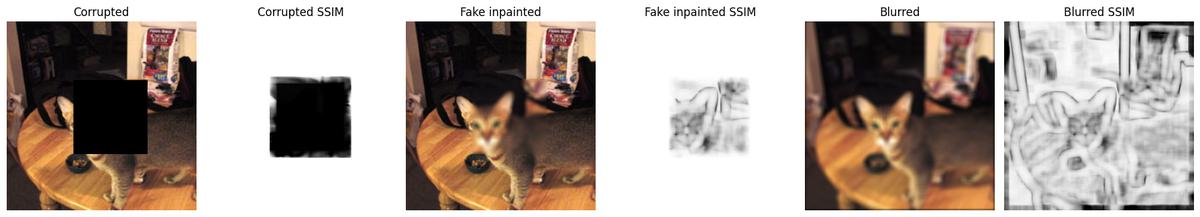

In [16]:
def show_image_ssim_pairs(x, images):
    xs, titles = [], []
    for name, img in images.items():
        m = ssim_map(x, img).mean(dim=1, keepdim=True).clamp(0, 1)
        m = m.repeat(1, 3, 1, 1)
        xs.extend([img, m])
        titles.extend([name, f"{name} SSIM"])
    show(xs, titles)

show_image_ssim_pairs(x, {"Corrupted": x_corrupted, "Fake inpainted": x_inpainted, "Blurred": x_blur})

Each pair shows a distorted image followed by its SSIM map. Bright regions in the SSIM map indicate high local structural similarity to the reference, while dark regions indicate low local similarity. This is useful for inpainting because a single full-image SSIM score can hide where the reconstruction fails. The map makes the spatial distribution of structural error visible, especially inside the missing region.

### Multi-Scale SSIM

SSIM compares local structure at one image scale. This is useful, but image quality is not always judged at a single resolution. Some errors affect fine texture and edges, while others affect larger shapes, object boundaries, or low-frequency structure. _Multi-Scale SSIM (MS-SSIM)_ extends SSIM by comparing images across several progressively downsampled versions. At high resolution, it can capture fine-detail differences; at lower resolutions, it focuses more on larger structural agreement. This makes MS-SSIM less tied to one fixed window size or one fixed image scale than ordinary SSIM. MS-SSIM asks: "Does the structure remain similar across several scales?" This is useful in restoration and inpainting because a result may preserve broad layout while losing texture, or preserve local texture while damaging larger structure. MS-SSIM was proposed to make structural similarity more flexible across viewing conditions and image scales.

## Learned Perceptual Metrics

Pixel-wise metrics compare images through direct numerical differences between corresponding pixels. Structural similarity metrics compare local image statistics such as brightness, contrast, and structure. Learned perceptual metrics compare images in a different space: instead of using raw pixels or hand-designed local statistics, they use feature representations extracted by neural networks.

The motivation is that two images can be visually similar even when they are not pixel-wise identical. This is especially important for image inpainting. A missing region may have more than one plausible reconstruction, and a model may generate a visually reasonable texture or object detail that does not exactly match the original reference pixels. Pixel-wise metrics may penalize such outputs strongly. Learned perceptual metrics try to measure whether two images are close in a feature space that better reflects visual similarity.

### Learned Perceptual Image Patch Similarity

_Learned Perceptual Image Patch Similarity (LPIPS)_ is a full-reference perceptual distance metric. It compares a reference image $x$ and a prediction $\hat{x}$ by passing both images through a pretrained neural network and measuring the distance between their intermediate feature activations. The method was introduced as a part of a broader study showing that deep network features can align well with human perceptual similarity judgments ([Zhang et al., 2018](https://arxiv.org/abs/1801.03924)).

MSE asks whether corresponding pixels are numerically close. SSIM asks whether local structures are statistically similar. LPIPS asks whether the two images are close in the representation space of a trained visual network. If the feature activations are similar, the images are treated as perceptually similar. If the feature activations are different, the images are treated as perceptually different. A simplified form of the metric can be written as

$$
\operatorname{LPIPS}(x,\hat{x}) =
\sum_l
\frac{1}{H_l W_l}
\sum_{i,j}
d_l
\left(
\phi_l(x)_{i,j},
\phi_l(\hat{x})_{i,j}
\right),
$$

where $\phi_l(\cdot)$ denotes the feature map extracted from layer $l$ of a pretrained network, $H_l$ and $W_l$ are the height and width of that feature map, and $d_l$ measures the distance between feature vectors at spatial location $(i,j)$. The actual LPIPS implementation uses normalized deep features and learned calibration weights, but the main idea is still feature-space distance rather than pixel-space error.

For PSNR, SSIM, and MS-SSIM, higher values usually mean better similarity. For LPIPS, lower values are better. A score close to zero means the reference and prediction are perceptually similar in deep feature space. A larger score means they are more perceptually different. The official [LPIPS implementation](https://github.com/richzhang/perceptualsimilarity) follows this interpretation.

For inpainting, LPIPS is useful because it can reward perceptual plausibility more than exact pixel matching. However, it should not replace pixel-wise and structural metrics. LPIPS depends on the pretrained network and the feature space used for comparison. It also does not guarantee physical, spectral, or semantic correctness. This matters, say, in satellite image restoration, where a visually plausible reconstruction may still be radiometrically or spectrally inaccurate. Therefore, LPIPS should be reported together with pixel-wise metrics, structural similarity metrics, and any domain-specific metrics required by the task.

In LPIPS, both images are first passed through a pretrained visual network, such as AlexNet, VGG, or SqueezeNet, and the distance is computed between intermediate feature maps. At each selected layer, the feature vectors are normalized along the channel dimension, then compared using a squared difference. The official LPIPS version also applies learned channel weights before averaging the distances across spatial locations and layers. These learned weights are the calibration part of LPIPS: they are trained to better match human perceptual similarity judgments. The pretrained model is chosen because it defines the feature space in which visual similarity is measured. AlexNet is commonly used as a default because it is lightweight, fast, and part of the official LPIPS setup; VGG is heavier but often gives strong perceptual features; SqueezeNet is smaller and faster. The official LPIPS authors report that these backbones give broadly similar perceptual scores, with linear calibration improving the result slightly.

In the next cell, we implement a simplified LPIPS-like distance using AlexNet features. This version keeps the main idea, normalized deep-feature distance, but does not include the learned LPIPS calibration weights.

In [17]:
from torchvision.models import alexnet, AlexNet_Weights

alex = alexnet(weights=AlexNet_Weights.DEFAULT).features.to(x.device).eval()


def imagenet_normalize(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
    return (x - mean) / std


def extract_alex_features(x, feature_layers=[1, 4, 7, 9, 11]):
    feats = []
    x = imagenet_normalize(x)
    for i, layer in enumerate(alex):
        x = layer(x)
        if i in feature_layers:
            feats.append(x)
    return feats


def normalize_features(f, eps=1e-10):
    return f / torch.sqrt((f ** 2).sum(dim=1, keepdim=True) + eps)


def lpips_custom(x, y, mask=None):
    if mask is not None:
        x = x * mask
        y = y * mask

    with torch.no_grad():
        x_feats = extract_alex_features(x)
        y_feats = extract_alex_features(y)

        distances = []
        for fx, fy in zip(x_feats, y_feats):
            fx = normalize_features(fx)
            fy = normalize_features(fy)
            d = ((fx - fy) ** 2).sum(dim=1, keepdim=True).mean()
            distances.append(d)

        return torch.stack(distances).mean()

In [19]:
metrics = {"PSNR": psnr, "SSIM": ssim, "LPIPS": lpips_custom}

scores = {}
for name, img in images.items():
    scores[name] = {
        "Full PSNR": psnr(x, img),
        "Hole PSNR": psnr(x, img, 1 - mask),
        "Full SSIM": ssim(x, img),
        "Hole SSIM": ssim(x, img, 1 - mask),
        "Full LPIPS": lpips_custom(x, img),
        "Hole LPIPS": lpips_custom(x, img, 1 - mask),
    }

plot_table(scores)

,Full PSNR,Hole PSNR,Full SSIM,Hole SSIM,Full LPIPS,Hole LPIPS
Reference,inf,inf,1.0000,1.0000,0.0000,0.0000
Corrupted,16.0887,7.9239,0.8319,0.0269,0.4516,0.7012
Fake inpainted,31.4302,23.2654,0.9670,0.7936,0.1510,0.1776
Blurred,23.9722,23.2654,0.7649,0.7826,0.5514,0.1776


The metrics do not rank the images in exactly the same way because they measure different properties. PSNR is derived from pixel-wise error, so it rewards numerical closeness. SSIM compares local brightness, contrast, and structure, so it is more sensitive to structural changes. LPIPS-like feature distance compares deep feature activations, so it measures perceptual difference in a learned feature space; unlike PSNR and SSIM, lower is better.

The previous implementation was a simplified LPIPS-like feature distance. It used normalized AlexNet feature differences, but it did not include the learned linear calibration weights used by the official LPIPS metric. For actual evaluation, we should use the official implementation. This keeps the metric consistent with restoration and inpainting papers that report LPIPS. We will use the AlexNet version because it is the default LPIPS backbone, is relatively lightweight, and is enough for this notebook. In a final experiment table, the backbone should be reported explicitly, for example as LPIPS-Alex.

In [20]:
!pip install -q lpips

In [21]:
import lpips

lpips_fn = lpips.LPIPS(net="alex").to(x.device)
lpips_fn.eval()

def to_lpips_range(x):
    return x * 2 - 1

def lpips_score(x, y, mask=None):
    if mask is not None:
        x = x * mask
        y = y * mask

    with torch.no_grad():
        return lpips_fn(to_lpips_range(x), to_lpips_range(y)).mean()

scores = {}

for name, img in images.items():
    scores[name] = {
        "Full LPIPS (official)": lpips_score(x, img),
        "Full LPIPS (custom)": lpips_custom(x, img),
        "Hole LPIPS (official)": lpips_score(x, img, 1 - mask),
        "Hole LPIPS (custom)": lpips_custom(x, img, 1 - mask),
    }

plot_table(scores)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


,Full LPIPS (official),Full LPIPS (custom),Hole LPIPS (official),Hole LPIPS (custom)
Reference,0.0000,0.0000,0.0000,0.0000
Corrupted,0.1911,0.4516,0.4612,0.7012
Fake inpainted,0.0780,0.1510,0.0997,0.1776
Blurred,0.3615,0.5514,0.0997,0.1776


The official LPIPS scores and the custom feature-distance scores differ because they are not the same metric, even though they follow the same general idea. The custom version computes an equally weighted distance between normalized AlexNet feature maps. It extracts features, normalizes them across channels, computes squared differences, and averages those differences across selected layers. The official LPIPS-Alex metric also compares intermediate AlexNet activations, but it adds learned linear calibration weights on top of those feature differences. These weights are trained from human perceptual similarity judgments, so different feature channels and layers are not treated equally. This changes the scale of the score and can also change how strongly different distortions are penalized.

The relative behavior is still consistent. The reference image has zero distance in both versions because it is compared with itself. The fake inpainted image has lower distance than the corrupted image because the hole is filled with a closer visual approximation. The blurred image has the same hole-region distance as the fake inpainted image because both contain the same blurred content inside the hole. However, the blurred image has a much larger full-image distance because blur changes the entire image, including the known region.

## Channel-Angle Metrics

Pixel-wise metrics compare direct numerical differences. Structural similarity metrics compare local image structure. Learned perceptual metrics compare deep feature activations. Another possible way to compare images is to treat the channel values at each pixel as a vector and compare the direction of that vector. This gives a channel-angle metric.

The most common version is _Spectral Angle Mapper (SAM)_. Despite the word "spectral," the basic idea is simple: for each pixel, compare the reference channel vector with the predicted channel vector by measuring the angle between them. For an RGB image, this means comparing vectors such as

$$
x = [R, G, B],
\qquad
\hat{x} = [\hat{R}, \hat{G}, \hat{B}].
$$

SAM is defined as

$$
\operatorname{SAM}(x,\hat{x})
=
\arccos
\left(
\frac{x^\top \hat{x}}
{\lVert x \rVert_2 \lVert \hat{x} \rVert_2}
\right).
$$

A smaller angle means the two channel vectors point in a similar direction. A larger angle means the relationship between the channels has changed. Therefore, SAM is a distance-like metric: lower is better. This is different from PSNR and SSIM, where higher is better.

SAM is less sensitive to pure magnitude changes than MSE or PSNR. If all channels are multiplied by the same positive constant, the vector becomes longer or shorter, but its direction remains the same. In that case, the SAM value can remain small even though the pixel values have changed. This makes SAM useful for detecting changes in channel relationships rather than raw brightness error.

In ordinary RGB inpainting, SAM should be treated as optional. It can show whether the color direction changes, but it is not usually one of the main inpainting metrics. The core inpainting metrics remain PSNR, SSIM or MS-SSIM, and LPIPS. SAM becomes more important when channels have stronger physical meaning (e.g. in remote sensing), because it measures whether the relative relationship between channels is preserved.

## Discussion

The metrics in this notebook are the main ones for paired image restoration and inpainting: MSE, RMSE, PSNR, SSIM, MS-SSIM, LPIPS, and optionally SAM. There are many other image quality metrics, but most of them are either less common in modern inpainting papers, more domain-specific, or better suited to a different evaluation setting.

Some related metrics were not developed in this notebook because they answer a different question from paired inpainting evaluation. _Inception Score (IS)_, _Fréchet Inception Distance (FID)_, and _Kernel Inception Distance (KID)_ are mainly distribution-level generative metrics. They evaluate sets of generated images, not one restored image against its own reference. IS uses an Inception classifier to reward confident and diverse generated samples. FID compares real and generated image distributions in Inception feature space. KID also compares real and generated feature distributions, but uses a kernel-based MMD distance instead of the Gaussian approximation used by FID.

These metrics are useful for generative modeling, GANs, diffusion models, and dataset-level realism analysis. They can be added for generative inpainting if the question is whether a large set of inpainted outputs looks realistic. However, they do not directly tell us whether a particular missing region was reconstructed correctly. For paired inpainting, they are complementary.

Metrics and losses are closely related. A metric is used to evaluate an output after it has been produced. A loss is used during training to optimize the model. The same idea can appear in both places, but the role is different. For example, MSE can be used as a metric and also as a training loss. L1 loss is common in restoration training because it often produces less excessive smoothing than L2 loss. Perceptual loss is related to LPIPS because both compare deep feature representations, but perceptual loss is used as an optimization objective. Style loss compares Gram matrices of deep features and is more related to texture statistics.

## Conclusion

This notebook covered the main metric families needed for paired image restoration and inpainting evaluation. Pixel-wise metrics such as MSE, RMSE, and PSNR measure direct numerical fidelity. Structural similarity metrics such as SSIM and MS-SSIM measure local and multi-scale structure. Learned perceptual metrics such as LPIPS measure distance in deep feature space. SAM measures angular difference between channel vectors and is useful when channel relationships matter.

For ordinary paired inpainting, the most practical reporting set is PSNR, SSIM or MS-SSIM, and LPIPS. These should be reported on the full image and on the hole region. Full-image scores describe the whole output, but they can hide poor reconstruction when the missing region is small. Hole-region scores focus on the actual reconstructed area and are usually more diagnostic for inpainting quality.

No single metric is sufficient. PSNR can reward overly smooth outputs because blur may reduce average pixel error. SSIM captures structure but can miss perceptual or semantic failures. LPIPS better reflects perceptual similarity, but it depends on pretrained feature representations. SAM captures channel-direction consistency, but it is optional for ordinary RGB inpainting. Distribution-level metrics such as IS, FID, and KID are useful for generative realism across datasets, but they do not replace paired reconstruction metrics. Loss functions are related to these ideas, but they belong in a separate training-loss notebook.